In [24]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Fonts (same system as viz/pl_scatter.py, postmortem_v2.ipynb)
for _path in ['/Users/admin/Library/Fonts/Roboto-Regular.ttf',
              '/Users/admin/Library/Fonts/Roboto-Bold.ttf']:
    try:
        fm.fontManager.addfont(_path)
    except Exception:
        pass

# Shared palette - datawrapper-style: accent colours stay saturated, structural
# greys (grid/axis/muted/ink) match the repo's chart house style
BLUE    = '#2a78d6'
ORANGE  = '#eb6834'
RED     = '#e34948'
C_GRID  = '#eeeeee'
C_AXIS  = '#cccccc'
C_MUTED = '#888888'
C_INK   = '#1a1a1a'
C_INK2  = '#666666'

plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'Roboto',
    'axes.edgecolor': C_AXIS,
    'axes.labelcolor': C_INK2,
    'text.color': C_INK,
    'xtick.color': C_INK2,
    'ytick.color': C_INK2,
    'xtick.major.size': 0,
    'ytick.major.size': 0,
    'axes.grid': True,
    'grid.color': C_GRID,
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
})


def _dw_style(ax, grid_axis='both'):
    """Datawrapper-style axis dressing: hide top/right spines, faint grid,
    no tick marks, muted tick labels - matches viz/pl_scatter.py."""
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color(C_AXIS)
    ax.spines['bottom'].set_color(C_AXIS)
    ax.tick_params(length=0, colors=C_INK2)
    ax.grid(axis=grid_axis, color=C_GRID, linewidth=0.8)
    ax.set_axisbelow(True)


def _dw_title(ax, title, subtitle=None, y=1.12, dy=0.055, size=13, sub_size=9.5):
    """Left-aligned bold title + grey subtitle sitting above the axes,
    matching the title block in viz/pl_scatter.py / postmortem_v2.ipynb."""
    ax.text(0, y, title, transform=ax.transAxes,
            fontsize=size, fontweight='bold', color=C_INK, va='bottom', ha='left')
    if subtitle:
        ax.text(0, y - dy, subtitle, transform=ax.transAxes,
                fontsize=sub_size, color=C_MUTED, va='bottom', ha='left')


DATA_DIR = Path("public_marathon_results")
CPH_DIR = DATA_DIR / "CopenhagenMarathon"
MY_BIB, MY_YEAR, MY_NAME = 6207, 2026, "Louis Porter"

## 1. Distribution of all marathon times

Boston is deliberately excluded: it's qualifying-time gated, not open/lottery entry
like the others, so its whole distribution is shifted faster - not a stand-in for
"the general marathon population" (median ~3:44 vs NYC's ~4:29; Boston's 90th
percentile barely reaches NYC's median). Copenhagen is open-entry, so it's included
here as one more race (its most recent edition, to stay one-snapshot-per-race like
the others - the full 11-year history is used in section 3).

In [25]:
def to_minutes(series):
    return pd.to_timedelta(series, errors="coerce").dt.total_seconds() / 60

def load_berlin():
    df = pd.read_csv(DATA_DIR / "Berlin/results-2019.csv", low_memory=False)
    return pd.DataFrame({
        "race": "Berlin", "year": df["year"],
        "gender": df["gender"].str[0].str.upper(),
        "age_band": np.nan,
        "time_min": to_minutes(df["time_full"]),
    })

def load_chicago():
    df = pd.read_csv(DATA_DIR / "Chicago/results-2018.csv", low_memory=False)
    return pd.DataFrame({
        "race": "Chicago", "year": df["year"],
        "gender": df["gender"].str[0].str.upper(),
        "age_band": df["division"],
        "time_min": to_minutes(df["time_full"]),
    })

def load_honolulu():
    df = pd.read_csv(DATA_DIR / "Honolulu/results-2019.csv", low_memory=False)
    return pd.DataFrame({
        "race": "Honolulu", "year": df["Year"],
        "gender": df["gender"].str[0].str.upper(),
        "age_band": df["division"],
        "time_min": to_minutes(df["time_full"]),
    })

def load_london():
    df = pd.read_csv(DATA_DIR / "London/results-2018.csv", low_memory=False)
    return pd.DataFrame({
        "race": "London", "year": df["year"],
        "gender": df["gender"].str[0].str.upper(),
        "age_band": df["division"],
        "time_min": to_minutes(df["time_full"]),
    })

def load_nyc():
    df = pd.read_csv(DATA_DIR / "New York City/results-2019.csv", low_memory=False)
    return pd.DataFrame({
        "race": "New York City", "year": df["Year"],
        "gender": df["gender"].str[0].str.upper(),
        "age_band": df["age"].astype("Int64").astype(str),
        "time_min": to_minutes(df["time_full"]),
    })

def load_portland():
    df = pd.read_csv(DATA_DIR / "Portland/results-2019.csv", low_memory=False)
    return pd.DataFrame({
        "race": "Portland", "year": 2019,
        "gender": df["Sex"].str[0].str.upper(),
        "age_band": df["Age"].astype("Int64").astype(str),
        "time_min": to_minutes(df["Chip Time"]),
    })

def load_cph_year(year):
    df = pd.read_csv(CPH_DIR / f"results-{year}.csv", dtype=str)
    return pd.DataFrame({
        "race": "Copenhagen", "year": year,
        "gender": df["category"].str[0],
        "age_band": df["category"].str[1:],
        "time_min": to_minutes(df["time"]),
    })

results = pd.concat(
    [load_berlin(), load_chicago(), load_honolulu(), load_london(), load_nyc(), load_portland(),
     load_cph_year(MY_YEAR)],
    ignore_index=True,
)
results = results.dropna(subset=["time_min"])
results = results[results["time_min"].between(90, 480)]  # drop obvious data errors (<1:30, >8h)

print(f"{len(results):,} finishers")
results["race"].value_counts()

220,406 finishers


race
New York City    53333
Chicago          44455
Berlin           43936
London           40034
Copenhagen       21613
Honolulu         15214
Portland          1821
Name: count, dtype: int64

In [26]:
print(results["time_min"].describe())
print("\nskew:", results["time_min"].skew())

count    220406.000000
mean        274.080066
std          63.072202
min         121.683333
25%         228.416667
50%         265.250000
75%         311.900000
max         479.983333
Name: time_min, dtype: float64

skew: 0.6623897465216481


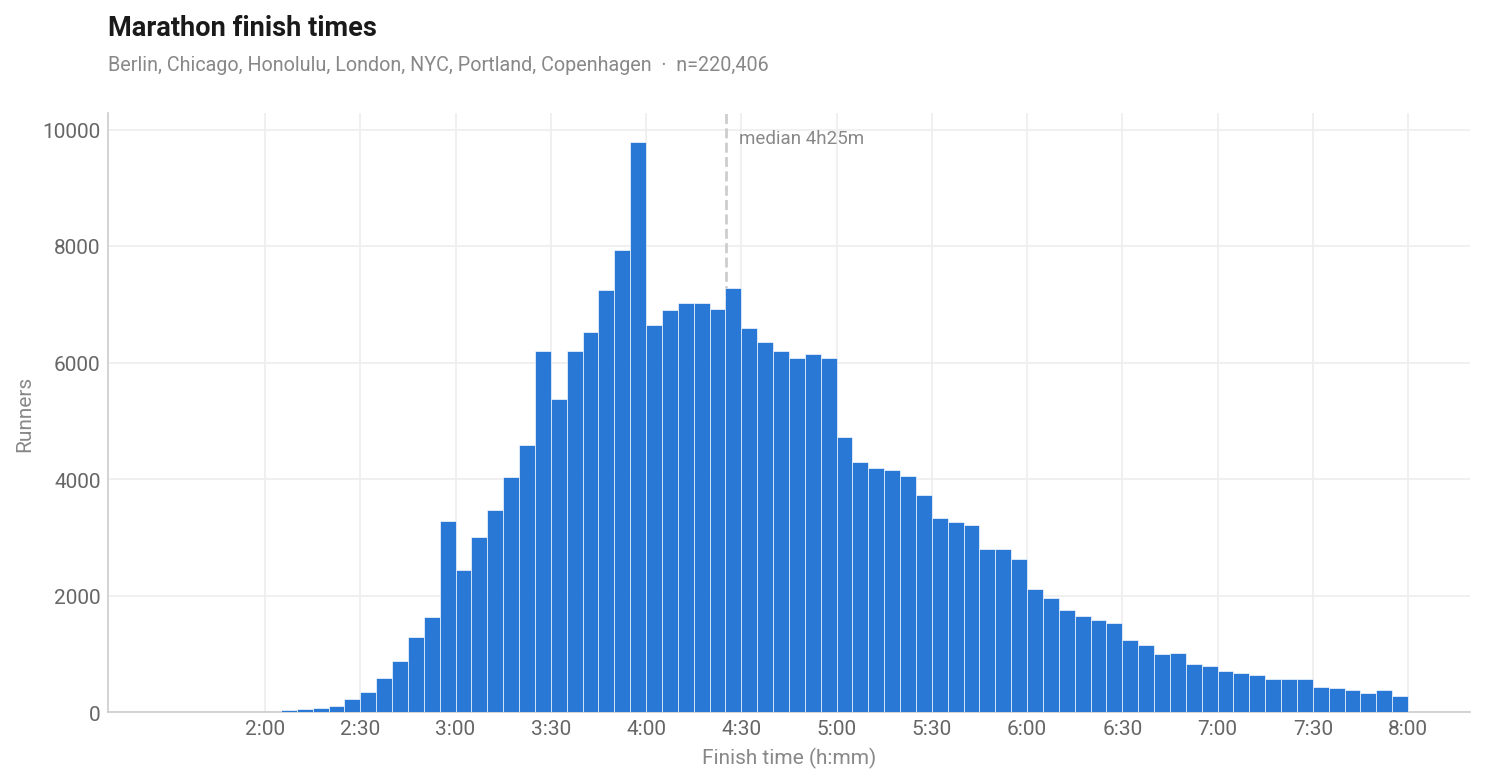

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.arange(90, 481, 5)
ax.hist(results["time_min"], bins=bins, color=BLUE, edgecolor="white", linewidth=0.3, zorder=3)

median = results["time_min"].median()
ax.axvline(median, color=C_AXIS, linewidth=1.3, linestyle="--", zorder=2)
median_h, median_m = divmod(round(median), 60)
ax.text(median + 4, ax.get_ylim()[1] * 0.95, f"median {median_h}h{median_m:02d}m",
        color=C_MUTED, fontsize=9)

xt = np.arange(120, 481, 30)
ax.set_xticks(xt)
ax.set_xticklabels([f"{t//60}:{t%60:02d}" for t in xt])
ax.set_xlabel("Finish time (h:mm)", fontsize=10, color=C_MUTED)
ax.set_ylabel("Runners", fontsize=10, color=C_MUTED)
_dw_title(ax, "Marathon finish times", f"Berlin, Chicago, Honolulu, London, NYC, Portland, Copenhagen  ·  n={len(results):,}")
_dw_style(ax, grid_axis="y")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

## 2. My performance vs. the whole population

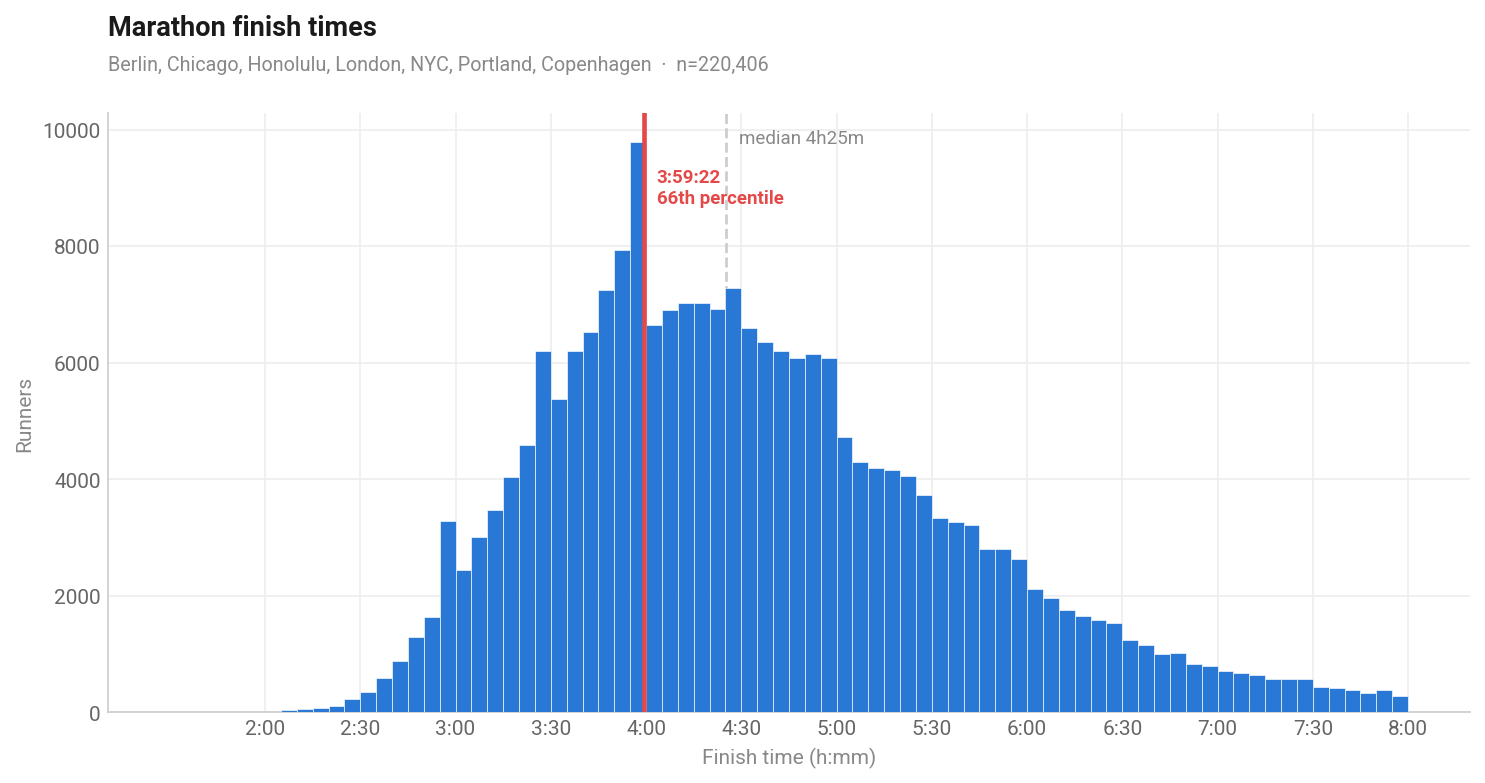

Copenhagen 2026: 3:59:22 -> faster than 66% of 220,406 runners across Berlin/Chicago/Honolulu/London/NYC/Portland/Copenhagen


In [33]:
cph_2026 = pd.read_csv(CPH_DIR / f"results-{MY_YEAR}.csv", dtype=str)
me_row = cph_2026[cph_2026["bib"] == str(MY_BIB)].iloc[0]
my_time = to_minutes(pd.Series([me_row["time"]])).iloc[0]

# "faster than X%" = fraction of the comparison group with a SLOWER time than yours
pct_all_pop = (results["time_min"] > my_time).mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(results["time_min"], bins=bins, color=BLUE, edgecolor="white", linewidth=0.3, zorder=3)

median = results["time_min"].median()
ax.axvline(median, color=C_AXIS, linewidth=1.3, linestyle="--", zorder=2)
median_h, median_m = divmod(round(median), 60)
ax.text(median + 4, ax.get_ylim()[1] * 0.95, f"median {median_h}h{median_m:02d}m",
        color=C_MUTED, fontsize=9)

ax.axvline(my_time, color=RED, linewidth=2.2, zorder=4)
ax.text(my_time + 4, ax.get_ylim()[1] * 0.85,
        f"{me_row['time']}\n{pct_all_pop:.0f}th percentile",
        color=RED, fontsize=9, fontweight="bold")

ax.set_xticks(xt)
ax.set_xticklabels([f"{t//60}:{t%60:02d}" for t in xt])
ax.set_xlabel("Finish time (h:mm)", fontsize=10, color=C_MUTED)
ax.set_ylabel("Runners", fontsize=10, color=C_MUTED)
_dw_title(ax, "Marathon finish times", f"Berlin, Chicago, Honolulu, London, NYC, Portland, Copenhagen  ·  n={len(results):,}")
_dw_style(ax, grid_axis="y")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

print(f"Copenhagen {MY_YEAR}: {me_row['time']} -> faster than {pct_all_pop:.0f}% of {len(results):,} runners "
      f"across Berlin/Chicago/Honolulu/London/NYC/Portland/Copenhagen")

## 3. My performance relative to just Copenhagen

The mixed-population comparison above is diluted by every age and both genders.
A fairer read is against the actual field you lined up with - and specifically
against your own age/gender category, which is the real competitive peer group.

In [29]:
def load_cph_full(path):
    year = int(path.stem.split("-")[1])
    df = pd.read_csv(path, dtype=str)
    df["year"] = year
    df["time_min"] = to_minutes(df["time"])
    df["gender"] = df["category"].str[0]
    df["age_band"] = df["category"].str[1:]
    for c in ["rank_sex", "rank_category"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

cph = pd.concat([load_cph_full(p) for p in sorted(CPH_DIR.glob("results-*.csv"))], ignore_index=True)
cph = cph.dropna(subset=["time_min"])
cph = cph[cph["time_min"].between(90, 480)]

print(f"{len(cph):,} Copenhagen finishers across {cph['year'].nunique()} editions ({cph['year'].min()}-{cph['year'].max()})")
cph.groupby("year")["time_min"].agg(n="count", median=lambda s: s.median() / 60).round(2)

127,000 Copenhagen finishers across 11 editions (2014-2026)


,n,median
year,,
2014,9624,3.98
2015,9226,3.98
2016,8478,4.21
2017,8154,4.04
2018,7413,4.14
2019,10806,4.16
2022,8497,3.96
2023,10123,3.99
2024,14560,3.92


In [30]:
me = cph[(cph["year"] == MY_YEAR) & (cph["bib"] == str(MY_BIB))].iloc[0]

field_2026 = cph[cph["year"] == MY_YEAR]
men_2026 = field_2026[field_2026["gender"] == me["gender"]]
cat_2026 = field_2026[field_2026["category"] == me["category"]]

pct_overall = (field_2026["time_min"] > my_time).mean() * 100
pct_gender = (men_2026["time_min"] > my_time).mean() * 100
pct_category = (cat_2026["time_min"] > my_time).mean() * 100

print(f"Copenhagen {MY_YEAR}: {me['time']} (bib {me['bib']}, category {me['category']})")
print(f"  faster than {pct_overall:.0f}% of the WHOLE Copenhagen field ({len(field_2026):,} finishers)")
print(f"  faster than {pct_gender:.0f}% of men ({len(men_2026):,})")
print(f"  faster than {pct_category:.0f}% of {me['category']} runners ({len(cat_2026):,}) <- your real peer group")

Copenhagen 2026: 3:59:22 (bib 6207, category M25-29)
  faster than 39% of the WHOLE Copenhagen field (21,613 finishers)
  faster than 32% of men (15,118)
  faster than 28% of M25-29 runners (3,561) <- your real peer group


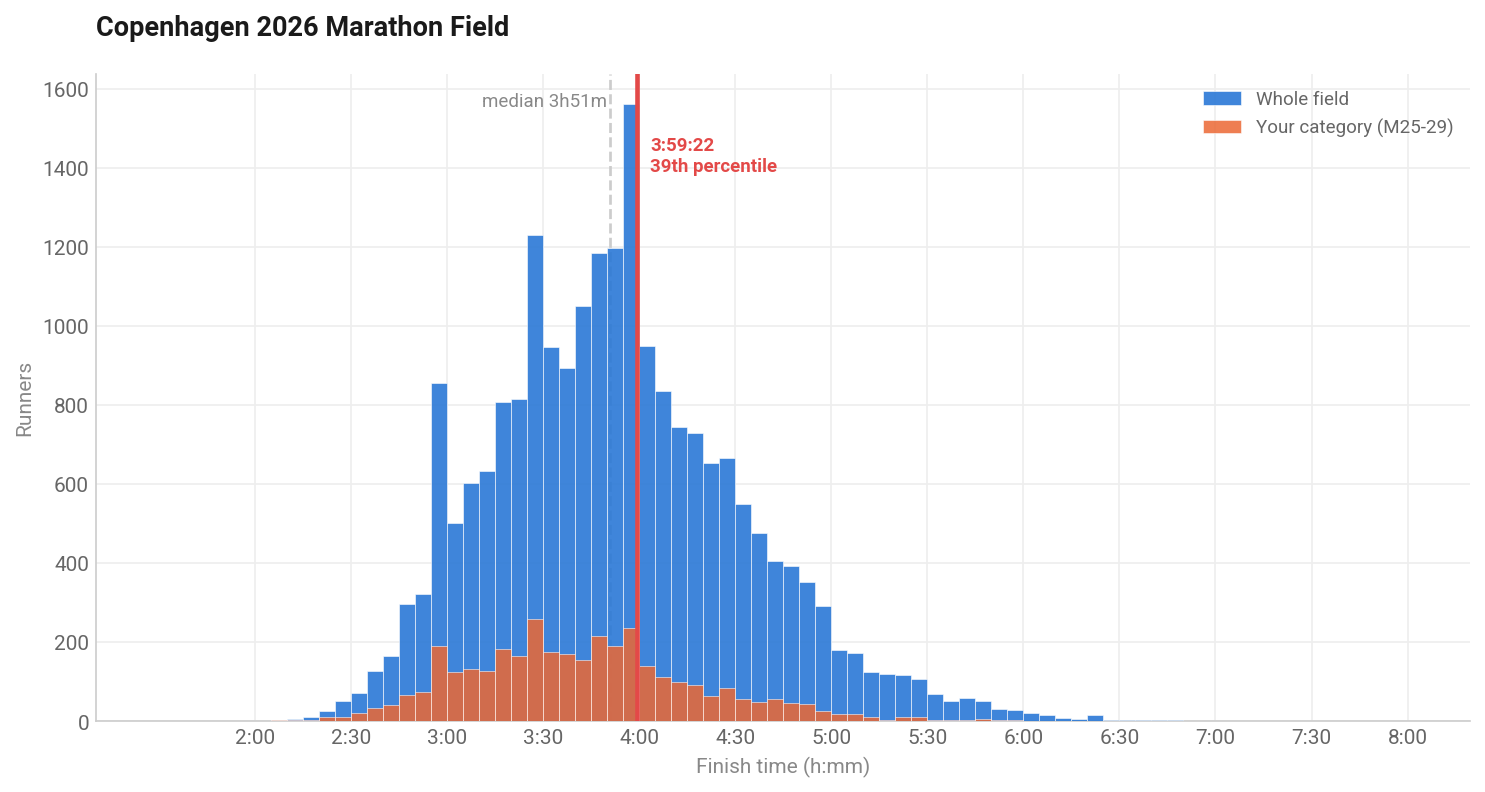

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(field_2026["time_min"], bins=bins, color=BLUE, alpha=0.9, label="Whole field", edgecolor="white", linewidth=0.3, zorder=3)
ax.hist(cat_2026["time_min"], bins=bins, color=ORANGE, alpha=0.85, label=f"Your category ({me['category']})", edgecolor="white", linewidth=0.3, zorder=3)

cph_median = field_2026["time_min"].median()
ax.axvline(cph_median, color=C_AXIS, linewidth=1.3, linestyle="--", zorder=2)
cph_median_h, cph_median_m = divmod(round(cph_median), 60)
ax.text(cph_median - 40, ax.get_ylim()[1] * 0.95, f"median {cph_median_h}h{cph_median_m:02d}m",
        color=C_MUTED, fontsize=9)

ax.axvline(my_time, color=RED, linewidth=2.2, zorder=4)
ax.text(my_time + 4, ax.get_ylim()[1] * 0.85, f"{me['time']}\n{pct_overall:.0f}th percentile",
        color=RED, fontsize=9, fontweight="bold")

ax.set_xticks(xt)
ax.set_xticklabels([f"{t//60}:{t%60:02d}" for t in xt])
ax.set_xlabel("Finish time (h:mm)", fontsize=10, color=C_MUTED)
ax.set_ylabel("Runners", fontsize=10, color=C_MUTED)
_dw_title(ax, "Copenhagen 2026 Marathon Field", y=1.05)
ax.legend(fontsize=9, loc="upper right", frameon=False, labelcolor=C_INK2)
_dw_style(ax, grid_axis="y")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

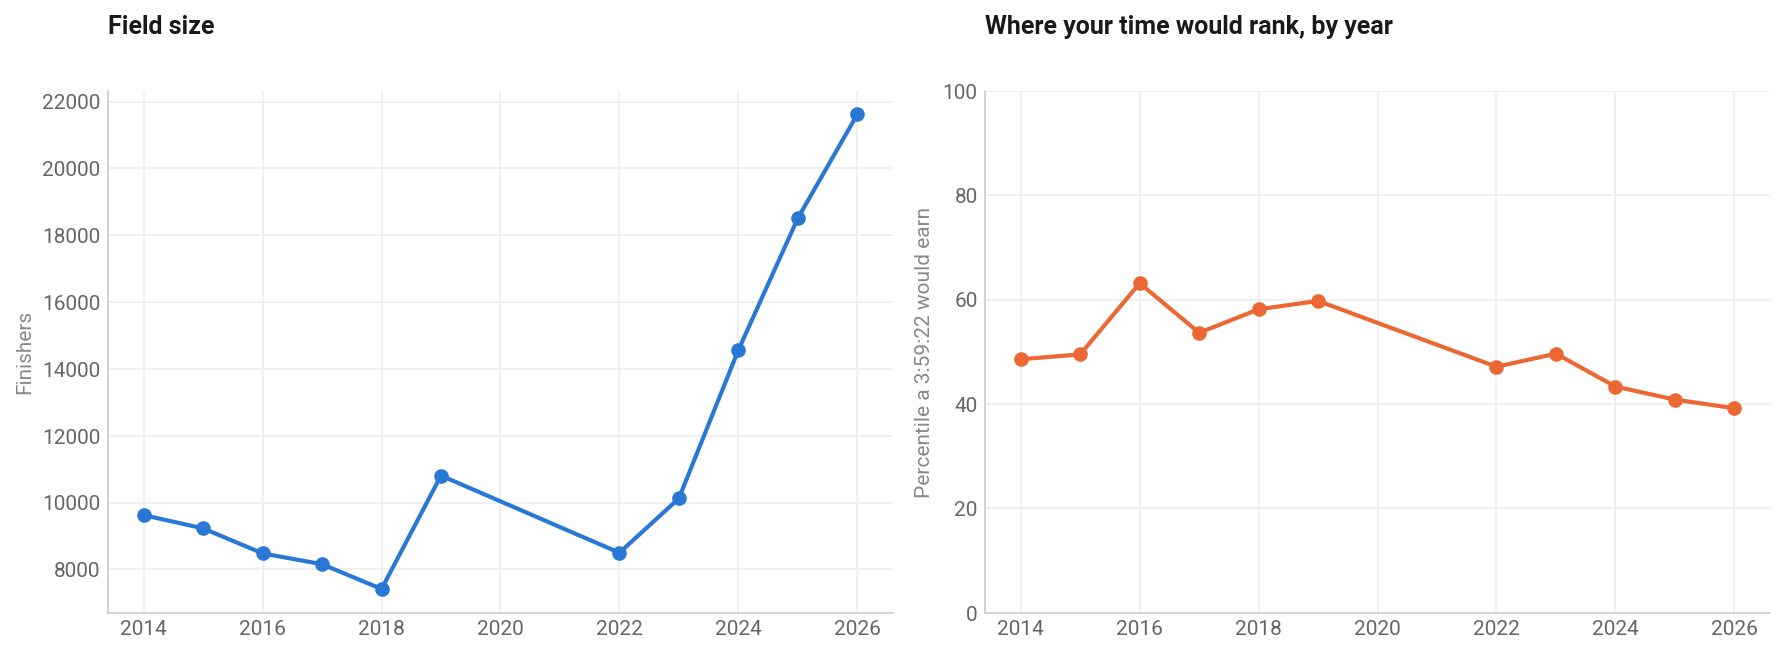

,n,median_min,pct_for_my_time
year,,,
2014,9624,238.6,48.6
2015,9226,239.0,49.5
2016,8478,252.9,63.1
2017,8154,242.6,53.6
2018,7413,248.6,58.1
2019,10806,249.9,59.7
2022,8497,237.6,47.1
2023,10123,239.2,49.6
2024,14560,235.0,43.3


In [32]:
# The race has grown a lot and gotten faster at the median every year - check
# whether "faster median" is a real fitness-of-the-field shift or just bigger
# fields pulling in a relatively similar mix, and see where 3:59:22 would have
# landed in every other edition.
trend = cph.groupby("year").agg(n=("time_min", "count"), median_min=("time_min", "median"))
trend["pct_for_my_time"] = cph.groupby("year")["time_min"].apply(lambda s: (s > my_time).mean() * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(trend.index, trend["n"], "o-", color=BLUE, linewidth=2, markersize=6, zorder=3)
ax1.set_ylabel("Finishers", fontsize=10, color=C_MUTED)
_dw_title(ax1, "Field size", y=1.1, dy=0.06, size=12, sub_size=9)
_dw_style(ax1, grid_axis="y")

ax2.plot(trend.index, trend["pct_for_my_time"], "o-", color=ORANGE, linewidth=2, markersize=6, zorder=3)
ax2.set_ylabel("Percentile a 3:59:22 would earn", fontsize=10, color=C_MUTED)
ax2.set_ylim(0, 100)
_dw_title(ax2, "Where your time would rank, by year", y=1.1, dy=0.06, size=12, sub_size=9)
_dw_style(ax2, grid_axis="y")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

trend.round(1)